# <center>Milestone 1<center>
Name: Janani Dhileepan

CID: 06026467

Date: 08/06/2026

## Introduction

### A. Research Proposal

**Overview:** I propose to write a paper on “Regulatory Vagueness and Fairness Drift: A Statistical Critique of Post-Deployment AI Monitoring" (working title).

The EU AI Act mandates post-deployment monitoring of high-risk AI systems for fairness but provides no statistical definitions at all. Not for fairness, not for drift, not for what constitutes a violation. In my dissertation, I will construct a fairness monitoring framework (a “smoke alarm”) using change point detection applied to fairness metrics over time. By doing so, I hope to demonstrate that the smoke alarm is sensitive to the choices embedded within it: which fairness metric is used, how each fairness metric is weighted, and which model is deployed. I hope to show that regulatory vagueness is not merely imprecise but actively exploitable; that is, a sophisticated actor can make pre-deployment choices that determine when, or whether, the alarm ever sounds.

**Motivation:** The EU AI Act, which provides the scaffolding for regulating AI systems, became legally binding across the EU in 2024 (European Commission, 2026). Due to it providing sparse details, individual companies are made to speculate how the Act should be used in practice with their own AI systems. In particular, the AI Act provides very few statistical details on how to classify, mitigate, and monitor high-risk AI systems.

For example, the Act states that fairness is one of the core principles for trustworthy and ethical AI. They define fairness as being AI systems that are “developed and used in a way that includes diverse actors and promotes equal access, gender equality and cultural diversity, while avoiding discriminatory impacts and unfair biases that are prohibited by Union or national law” (European Union, 2024, p.8).

Furthermore, Article 9 of the Act states that “A risk management system shall be… maintained in relation to high-risk AI systems… \[and\] shall comprise the identification and analysis of the known and the reasonably foreseeable risks that the high-risk AI system can pose to health, safety or fundamental rights.” (European Union, 2024). Article 72 states that “Providers shall establish and document a post-market monitoring system… which allow the provider to evaluate the continuous compliance of AI systems.” (European Union, 2024). These two articles, in combination with fairness being a key principle in compliant and trustworthy AI, suggests that the Act requires post-deployment monitoring of high-risk AI systems to ensure fairness.

The articles do not include any statistical definitions of fairness, drift from fairness, or what constitutes a violation. As a result, no two monitoring systems will look alike, in both rigour and sensitivity, especially as it is well-established in fairness literature that all definitions of fairness cannot be simultaneously satisfied (Chouldechova, 2017). A strategic company, therefore, may use this vagueness to construct a monitoring system that ensures, post-deployment, that their AI system appears compliant with maintaining fairness standards.

In this paper, I wish to illustrate that a post-deployment monitoring system is sensitive to fairness metrics, weightings, and model choice, thereby highlighting the mechanisms by which such a monitoring system optimised for apparent compliance rather than genuine fairness can be created.

**Proposed Pipeline:**

Step 1 (Pre-Deployment Algorithms): I plan to use the Home Mortgage Disclosure Act (HMDA) dataset, which spans 2007 to 2017 (for a total of 11 discrete years), to create a high-risk AI. The AI will decide whether someone should be approved or denied for a loan. To build this AI, I will treat 2007 as the pre-deployment period and use logistic regression, followed by a neural network, to classify whether someone should be approved or denied a loan.

Step 2 (Pre-Deployment Fairness Metrics): Using the trained algorithms, I wish to measure whether they treat all sensitive characteristics fairly (e.g., whether women get approved for a loan at the same rate as men). To do so, I will create a fairness metric, which will be a composite score of different fairness measures. Chouldechova’s (2017) impossibility theorem states that not all fairness measures can be simultaneously satisfied; therefore, my composite fairness metric requires explicit weighting choices.

Step 3 (Post-Deployment Measures): For the 2008-2017 data, which I will treat as the post-deployment period, I will use the trained algorithms produced from the 2007 data and recalculate the fairness metrics. For each year, I will run change point detection analysis and conduct a hypothesis test to see if/when the fairness drifts, which I will refer to as my “smoke alarm”. I will need to answer the two following questions:

1.	Should the baseline against which the change point analysis and the hypotheses tests are run be 2007, or should they be the previous year? The former doesn’t reward improvements to fairness over time (e.g. fairness in 2017 will be measured using fairness in 2007), but the latter implies that creeping fairness drift over time will not be properly identified.
2.	Should the hypothesis test require that fairness improves over time, or that it does not deteriorate over time? The standard in change point literature is the latter but suggests that whatever level of unfairness exists in the baseline is an acceptable level of unfairness.

Step 4 (Post-Hoc Analysis): I wish to run a Monte Carlo simulation to simulate how pre-deployment (2007) weighting choices for the fairness metric affect post-deployment (2008-2017) alarm behaviour. This, combined with a comparison of the neural network and logistic regression algorithms, will demonstrate that different weightings and different algorithm choices will determine when, or whether, the alarm rings. 

Step 5 (Time-Dependent Step): If there is enough time, I will re-run the experiment on a different dataset outside of credit scoring to demonstrate that the high-risk AI domain, too, will determine the smoke-alarm behaviour.

**Individual Contribution:** Below is the list of contributions that my work will add to the existing literature:

• The creation of a bespoke fairness measure. While each fairness metric within the fairness measure is well-established, the combination, along with their weightings, are an original formalisation for my research.

• The application of change point detection to fairness metrics over time. While both change point detection and measuring fairness are well-established fields, my paper will combine them for the first time to my knowledge.

• The Monte Carlo simulation linking pre-deployment weighting choices to post-deployment behaviour, making explicit one of the core arguments of my research: pre-deployment choices can be gamed to pre-emptively choose post-deployment alarm behaviour.

• The empirically backed regulatory critique of the EU AI Act’s vagueness, i.e., demonstrating statistically the mechanism of exploitability.

### B. Zip File Structure

The zip file attached includes: [TO BE FILLED IN]

### C. Notebook Structure

The structure of this Notebook is as follows: [TO BE FILLED IN]

## Data

### A. Data Explanation

The data used are the US Home Mortgage Disclosure Act (HMDA) data. The data contains information on whether individuals were approved for a loan, as well as key individual information such as demographics (race, sex, and ethnicity), income, and loan amount. To note is that age is a missing variable in the HMDA data.

The HMDA “requires many financial institutions to maintain, report, and publicly disclose loan-level information about mortgages” (Consumer Financial Protection Bureau, 2024). As a result, the data contains millions of entries and spans many decades (Consumer Financial Protection Bureau, 2024).

Data before 2007 are hard to find and standardise. In 2007, there was a change to how the data were collated, making it more publicly accessible and standardised. In 2018, there was once again a change, in which more fields were included, such as new property types and more distinct borrower demographics (National Credit Union Administration, 2019). As this data currently reaches 2024, there are only seven distinct years of data with the new fields.

Merging the 2007-2017 data with the 2018-2024 data is methodologically complex, as there are multiple mismatched fields and significantly more missing data in the 2018-2024 data. Furthermore, as my analysis needs only a pre-deployment period and a sufficiently long post-deployment period, merging will add little value to my analysis. As a result, I use only the 2007-2017 data, define the pre-deployment period as 2007, and the post-deployment period as 2008-2017 (10 years).

### B. Data Cleaning

The Python file in the Zip file (“clean_hmda_2007_2017.py”) merges all eleven years of data, conducts preliminary cleaning, and treats missing variables.

The variables retained in the data are year, action taken, race, sex, ethnicity, applicant income, loan amount, loan type, lien status, and tract-to-MSA/MD income.

Loan type encompasses, for example, conventional loans and VA-Guaranteed loans. A lien is a legal hold on an asset or property by a creditor to ensure payment of the loan; lien status, therefore, describes whose asset is being held (e.g. secured by one’s own lien vs. not secured by a lien). A tract is a neighbourhood; tract-to-MSA/MD income describes the ratio of income in the tract to the income in the Metropolitan Statistical Area or Metropolitan Division. The tract-to-MSA/MD income is therefore a proxy for neighbourhood wealth.

Missing data are dealt with in two ways: for variables that have missing data outside the sensitive information fields, namely race, sex, and ethnicity, rows with missing data are dropped as they often encompass such a negligible percentage of the entire dataset that listwise deletion introduces negligible bias. There are, however, large volumes of rows with missing data in sensitive fields. Treating such data using standard missing data treatments is ethically risky (for example, it is inappropriate to assume one’s race from their income); therefore, the data are coded as missing and are treated as a specific sub-group within the sensitive fields. As my algorithms will be trained on the action taken field, I retain only those observations with which the algorithms have a complete basis for classification (e.g. when the action taken is that the file is closed for incompleteness, the row is dropped).

For a complete summary list of the cleaning decisions made, please refer to Appendix 1: Cleaning Decisions on Raw Data.

### C. Exploratory Data Analysis

In this section, I discuss key findings during exploratory data analysis.

In [1]:
import os
os.getcwd()
os.chdir("../src")

In [2]:
%%capture
%run eda_hmda_2007_2017.ipynb

#### I. Continuous Variables EDA

The three continuous variables are: income, loan amount, and tract-to-MSA/MD income. All three variables are log-transformed as they are right-skewed distributions. This is to be expected as lower incomes are more common than higher incomes.

Income and loan amount have clear outlier values (values above USD $5 million), and these are dropped. The cut-off was chosen conservatively: while it may be plausible to have values higher than this, they are unlikely, and dropping these entries are negligibly few, implying that dropping them will introduce negligible bias into the dataset. Tract-to-MSA/MD income has some values of 0 (implying that the income is 0, which is impossible as the lowest income is USD $1,000). These rows are dropped.

The histograms below show all three log-transformed variables with outliers removed. They are now roughly normally distributed, which is a core requirement for regressions.

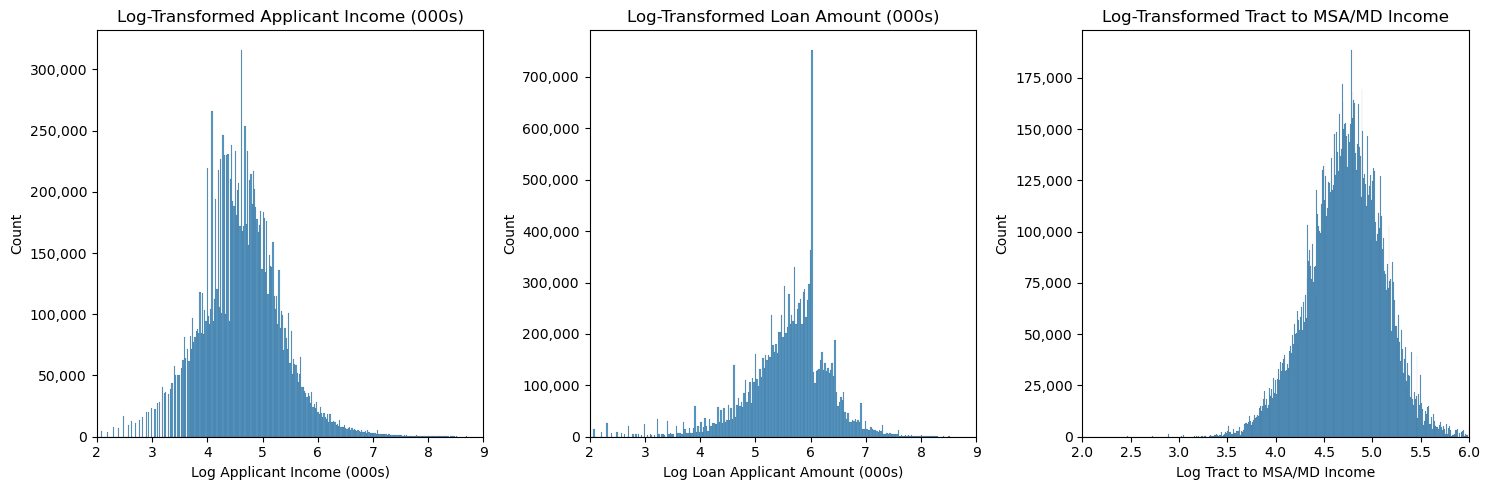

In [3]:
fig_cont

Note the spike in loan applicant amounts, which corresponds to around USD $417,000. This amount is the "conforming loan limit", i.e., the maximum size loan Fannie Mae and Freddie Mac would purchase, as it is easy to sell off. Loan requests just above that limit are shifted down to the conforming loan limit to get better interest rates. This is not an error of the data, but rather a facet of the loan market. To corroborate the existence of the conforming loan limit, the data frame below displays the spike amount at each year, along with the actual conforming loan limit as reported by the US Government (Federal Housing Finance Agency, 2024). Any marginal differences are due to binning decisions.

In [7]:
peak_df

,Year,Peak log loan,Peak loan (USD),Conforming loan limits (USD)
0,2007,6.03,415715.03,417000
1,2008,6.03,415715.03,417000
2,2009,6.03,415715.03,417000
3,2010,6.03,415715.03,417000
4,2011,6.03,415715.03,417000
5,2012,6.03,415715.03,417000
6,2013,6.03,415715.03,417000
7,2014,6.03,415715.03,417000
8,2015,6.03,415715.03,417000
9,2016,6.03,415715.03,417000


#### II. Categorical Variables EDA

The outcome variable is bucketed so that approved loans that borrowers accepted and approved loans that borrowers ultimatey did not accept become approved loans. Therefore action_taken == 1 correponds to approved loans and action_taken == 0 corresponds to denied loans.

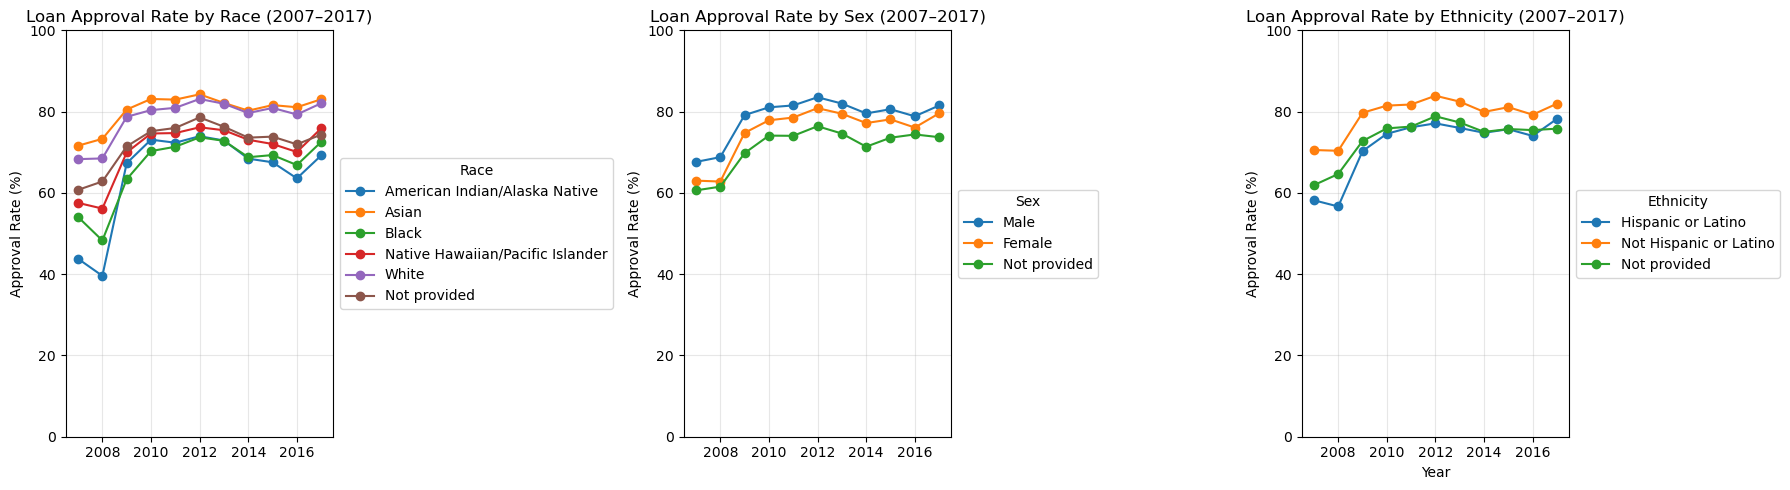

In [9]:
fig_sensitive_time

## Analysis

### A. Logistic Regression

### B. Fairness Metrics

## Future Steps

### A. Pipeline

### B. Questions

## Summary

## References

## Appendix